In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('./deeplearning.mplstyle')
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from lab_utils_common import dlc
from lab_coffee_utils import load_coffee_data, plt_roast, plt_prob, plt_layer, plt_network, plt_output_unit
import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)
tf.autograph.set_verbosity(0)

In [2]:
X,Y = load_coffee_data();
print(X.shape, Y.shape)

(200, 2) (200, 1)


In [3]:
print(X)

[[185.32  12.69]
 [259.92  11.87]
 [231.01  14.41]
 [175.37  11.72]
 [187.12  14.13]
 [225.91  12.1 ]
 [208.41  14.18]
 [207.08  14.03]
 [280.6   14.23]
 [202.87  12.25]
 [196.7   13.54]
 [270.31  14.6 ]
 [192.95  15.2 ]
 [213.57  14.28]
 [164.47  11.92]
 [177.26  15.04]
 [241.77  14.9 ]
 [237.    13.13]
 [219.74  13.87]
 [266.39  13.25]
 [270.45  13.95]
 [261.96  13.49]
 [243.49  12.86]
 [220.58  12.36]
 [163.59  11.65]
 [244.76  13.33]
 [271.19  14.84]
 [201.99  15.39]
 [229.93  14.56]
 [204.97  12.28]
 [173.19  12.22]
 [231.51  11.95]
 [152.69  14.83]
 [163.42  13.3 ]
 [215.95  13.98]
 [218.04  15.25]
 [251.3   13.8 ]
 [233.33  13.53]
 [280.24  12.41]
 [243.02  13.72]
 [155.67  12.68]
 [275.17  14.64]
 [151.73  12.69]
 [151.32  14.81]
 [164.9   11.73]
 [282.55  13.28]
 [192.98  11.7 ]
 [202.6   12.96]
 [220.67  11.53]
 [169.97  12.34]
 [209.47  12.71]
 [232.8   12.64]
 [272.8   15.35]
 [158.02  12.34]
 [226.01  14.58]
 [158.64  12.24]
 [211.66  14.17]
 [271.95  14.97]
 [257.16  11.7

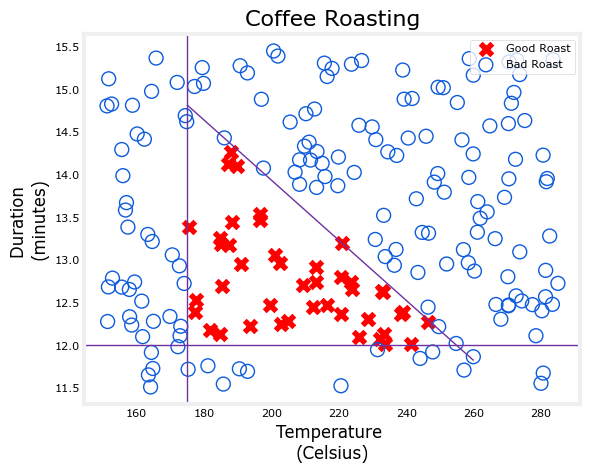

In [4]:
plt_roast(X,Y)

In [5]:
print(Y)

[[1.]
 [0.]
 [0.]
 [0.]
 [1.]
 [1.]
 [0.]
 [0.]
 [0.]
 [1.]
 [1.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [1.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [1.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [1.]
 [0.]
 [0.]
 [1.]
 [1.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [1.]
 [1.]
 [0.]
 [0.]
 [1.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [1.]
 [1.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [1.]
 [0.]
 [1.]
 [1.]
 [0.]
 [1.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [1.]
 [1.]
 [0.]
 [0.]
 [0.]
 [1.]
 [1.]
 [0.]
 [0.]
 [1.]
 [0.]
 [0.]
 [1.]
 [0.]
 [0.]
 [0.]
 [1.]
 [0.]
 [0.]
 [0.]
 [0.]
 [1.]
 [0.]
 [0.]
 [0.]
 [0.]
 [1.]
 [0.]
 [0.]
 [1.]
 [0.]
 [0.]
 [1.]
 [0.]
 [0.]
 [0.]
 [1.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [1.]
 [0.]
 [0.]
 [0.]
 [1.]
 [0.

In [6]:
print(f"Temperature Max, Min pre normalization: {np.max(X[:,0]):0.2f}, {np.min(X[:,0]):0.2f}")
print(f"Duration    Max, Min pre normalization: {np.max(X[:,1]):0.2f}, {np.min(X[:,1]):0.2f}")
norm_l = tf.keras.layers.Normalization(axis=-1)
norm_l.adapt(X)  # learns mean, variance
Xn = norm_l(X)
print(f"Temperature Max, Min post normalization: {np.max(Xn[:,0]):0.2f}, {np.min(Xn[:,0]):0.2f}")
print(f"Duration    Max, Min post normalization: {np.max(Xn[:,1]):0.2f}, {np.min(Xn[:,1]):0.2f}")

Temperature Max, Min pre normalization: 284.99, 151.32
Duration    Max, Min pre normalization: 15.45, 11.51
Temperature Max, Min post normalization: 1.66, -1.69
Duration    Max, Min post normalization: 1.79, -1.70


In [7]:
Xt=np.tile(Xn,(1000,1))
Yt=np.tile(Y,(1000,1))
print(Xt.shape, Yt.shape)

(200000, 2) (200000, 1)


In [8]:
tf.random.set_seed(1234)

In [9]:
import tensorflow as tf

In [10]:
model = Sequential(
    [
        tf.keras.Input(shape=(2,)),
        Dense(3,activation='sigmoid',name='layer1'),
        Dense(1,activation='sigmoid',name='output')
    ]
)

In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ layer1 (Dense)                  │ (None, 3)              │             9 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13 (52.00 B)

 Trainable params: 13 (52.00 B)

 Non-trainable params: 0 (0.00 B)

In [12]:
L1_num_params = 2 * 3 + 3   # W1 parameters  + b1 parameters
L2_num_params = 3 * 1 + 1   # W2 parameters  + b2 parameters
print("L1 params = ", L1_num_params, ", L2 params = ", L2_num_params  )

L1 params =  9 , L2 params =  4


In [18]:
W1, b1 = model.get_layer("layer1").get_weights()
W2, b2 = model.get_layer("output").get_weights()
print(f"W1{W1.shape}:\n", W1, f"\nb1{b1.shape}:", b1)
print(f"W2{W2.shape}:\n", W2, f"\nb2{b2.shape}:", b2)

W1(2, 3):
 [[ 0.91 -0.58  1.07]
 [-0.96 -0.87 -0.27]] 
b1(3,): [0. 0. 0.]
W2(3, 1):
 [[-0.03]
 [ 0.24]
 [ 1.15]] 
b2(1,): [0.]


In [20]:
model.compile(
    loss = tf.keras.losses.BinaryCrossentropy(),
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.01),
)

model.fit(
    Xt,Yt,            
    epochs=10,
)

Epoch 1/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 36s 5ms/step - loss: 0.1945
Epoch 2/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 121s 19ms/step - loss: 0.1208
Epoch 3/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 81s 9ms/step - loss: 0.0721
Epoch 4/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 50s 8ms/step - loss: 0.0199
Epoch 5/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 89s 9ms/step - loss: 0.0126
Epoch 6/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 106s 13ms/step - loss: 0.0089
Epoch 7/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 52s 8ms/step - loss: 0.0064
Epoch 8/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 111s 13ms/step - loss: 0.0047
Epoch 9/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 53s 8ms/step - loss: 0.0034
Epoch 10/10
6250/6250 ━━━━━━━━━━━━━━━━━━━━ 74s 7ms/step - loss: 0.0025


In [21]:
w1, b1 = model.get_layer("layer1").get_weights()
w2, b2 = model.get_layer("output").get_weights()

print("W1: \n", W1, "\nb1:", b1)
print("W2: \n",W2, "\nb2:", b2)

W1: 
 [[ 0.91 -0.58  1.07]
 [-0.96 -0.87 -0.27]] 
b1: [-11.3    1.83  13.25]
W2: 
 [[-0.03]
 [ 0.24]
 [ 1.15]] 
b2: [-12.49]


In [22]:
X_test = np.array([
    [200,13.9],  # positive example
    [200,17]])   # negative example
X_testn = norm_l(X_test)
predictions = model.predict(X_testn)
print("predictions = \n", predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 470ms/step
predictions = 
 [[9.74e-01]
 [5.63e-08]]


In [23]:
yhat = np.zeros_like(predictions)
for i in range(len(predictions)):
    if predictions[i] >= 0.5:
        yhat[i] = 1
    else:
        yhat[i] = 0
        
print(f"decisions = \n{yhat}")

decisions = 
[[1.]
 [0.]]


In [24]:
yhat = (predictions >= 0.5).astype(int)
print(f"decisions = \n{yhat}")

decisions = 
[[1]
 [0]]


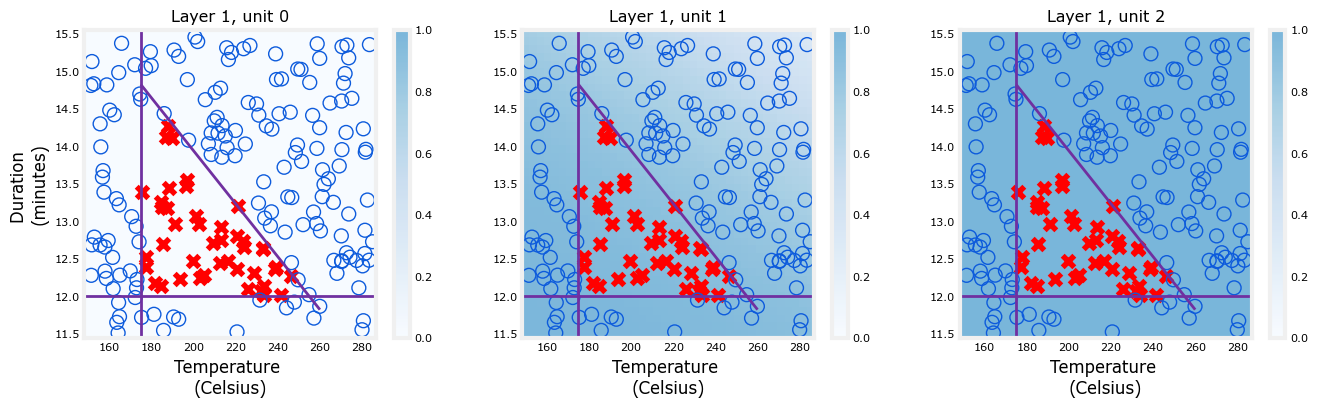

In [25]:
plt_layer(X,Y.reshape(-1,),W1,b1,norm_l)

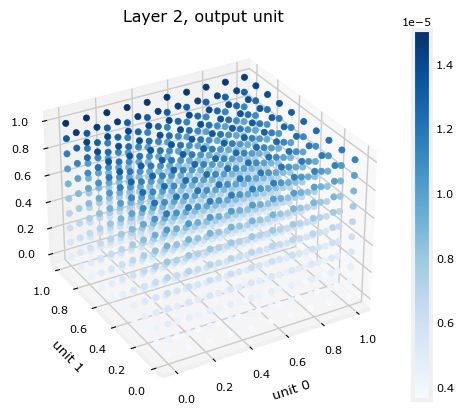

In [26]:
plt_output_unit(W2,b2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 748ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 533ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0

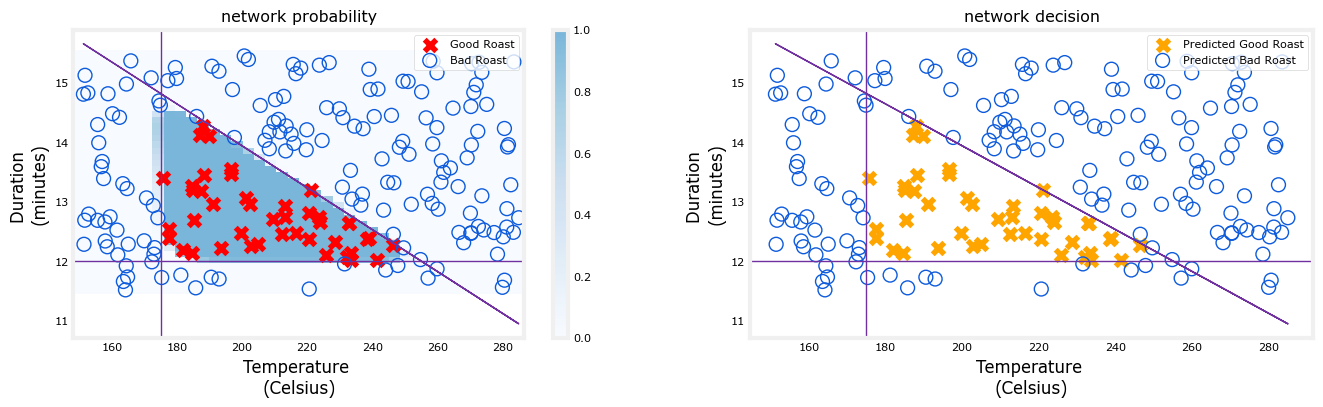

In [27]:
netf= lambda x : model.predict(norm_l(x))
plt_network(X,Y,netf)